Note: code snippets and content are on basis of a RAG course available on DataCamp. Also some notes are AI generated.


# Part 1: Building RAG applications with Langchain


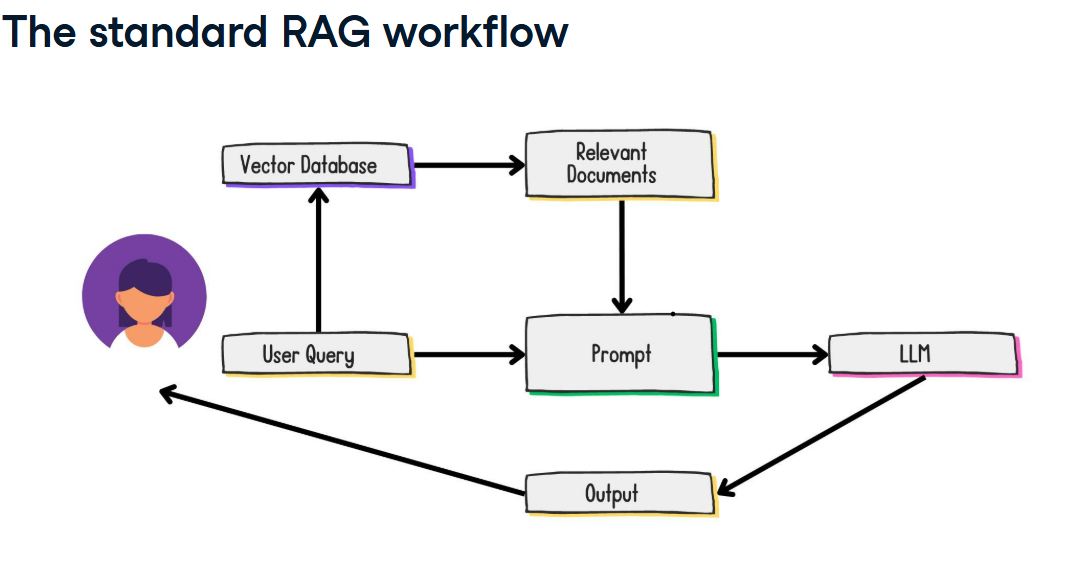

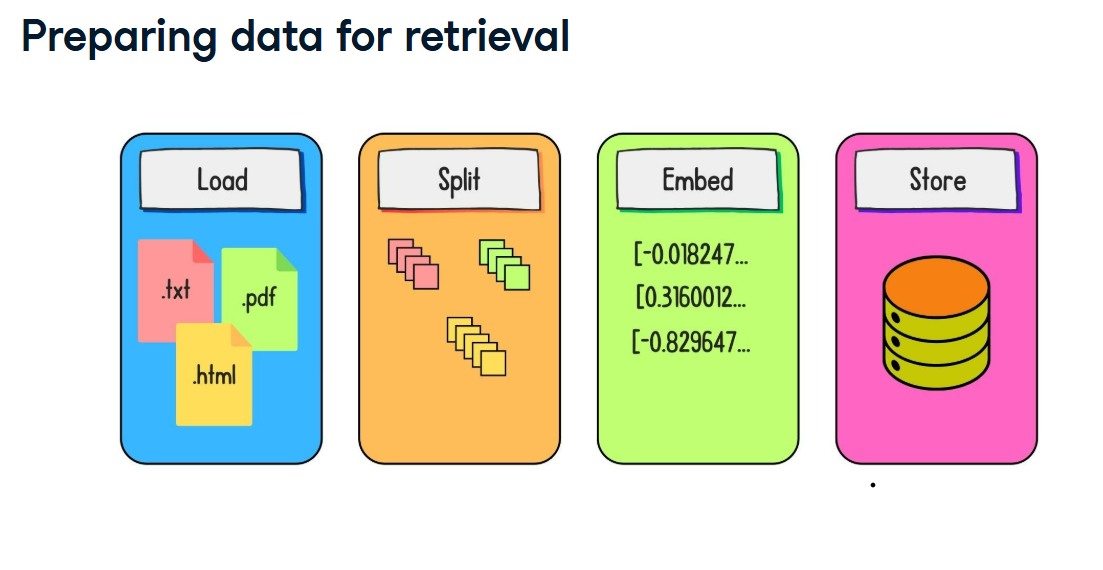

### Document loaders
LangChain document loaders facilitate the integration of documents into AI systems. These loaders handle various file types, including standard formats like CSV and PDFs, as well as specialized formats supported by third-party providers, such as Amazon S3 files, Jupyter notebooks, and audio transcripts. 
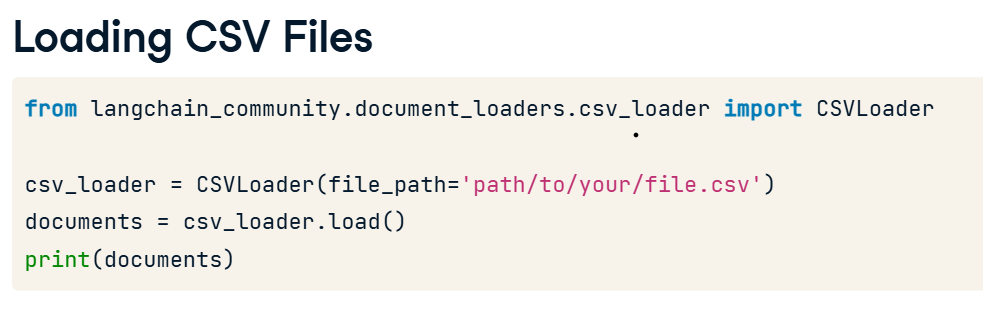

Likewise, we can use PyPDFLoader to load pdf files and UnstructuredHTMLLoader to load html files

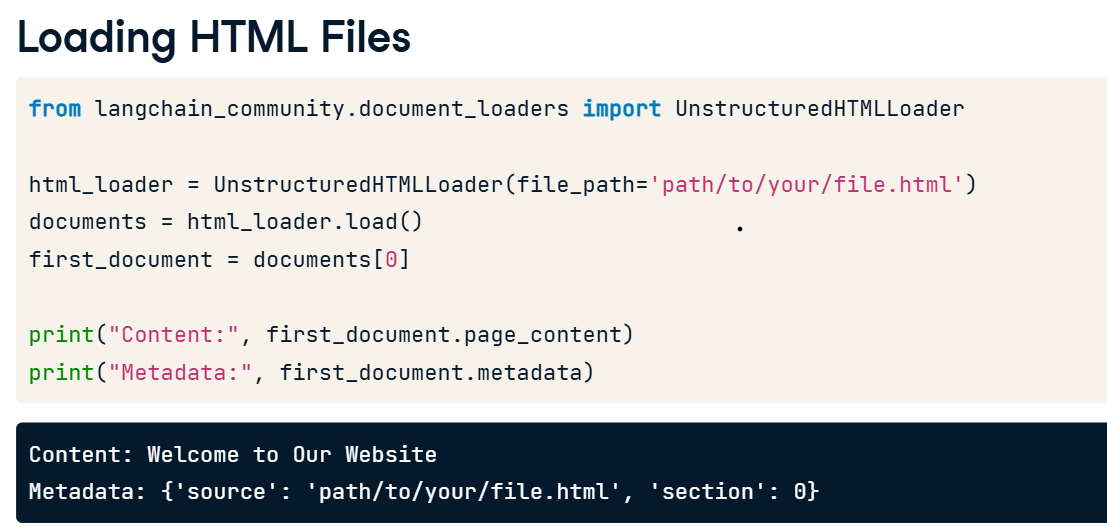

### Text splitting, embeddings and vector storage
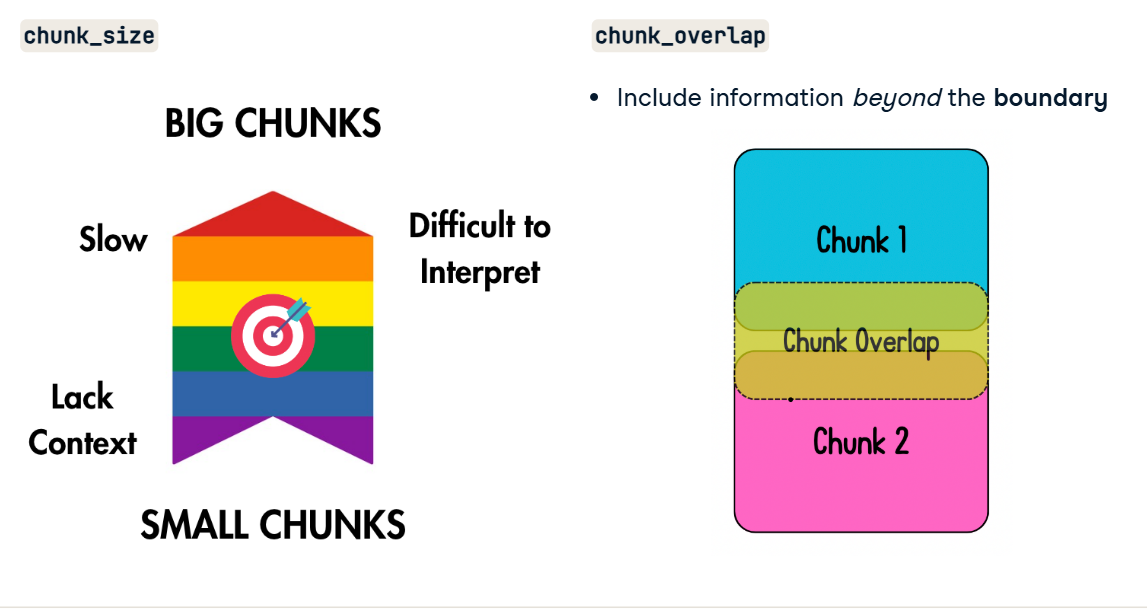

For text splitting, we can use CharacterTextSplitter and RecursiveCharacterTextSplitter.
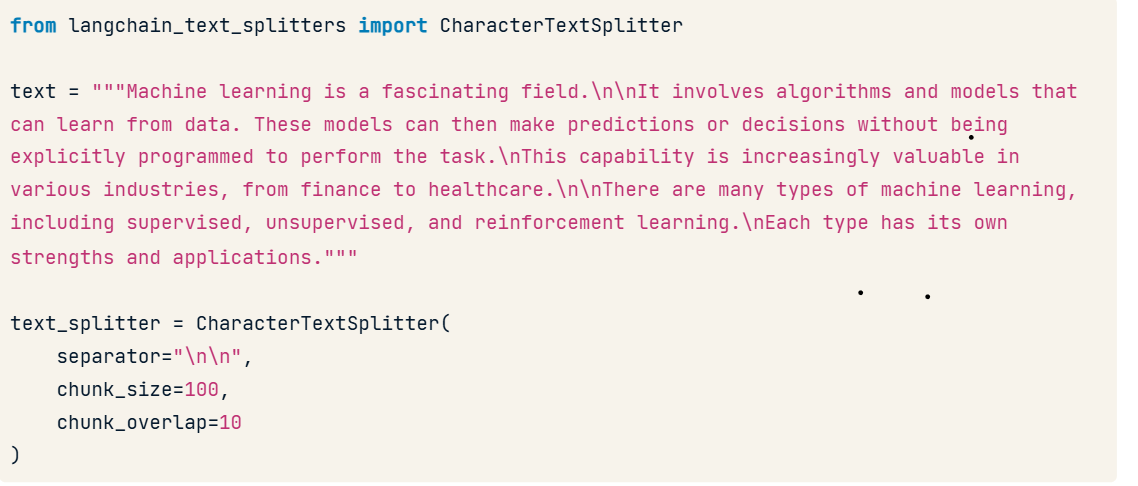
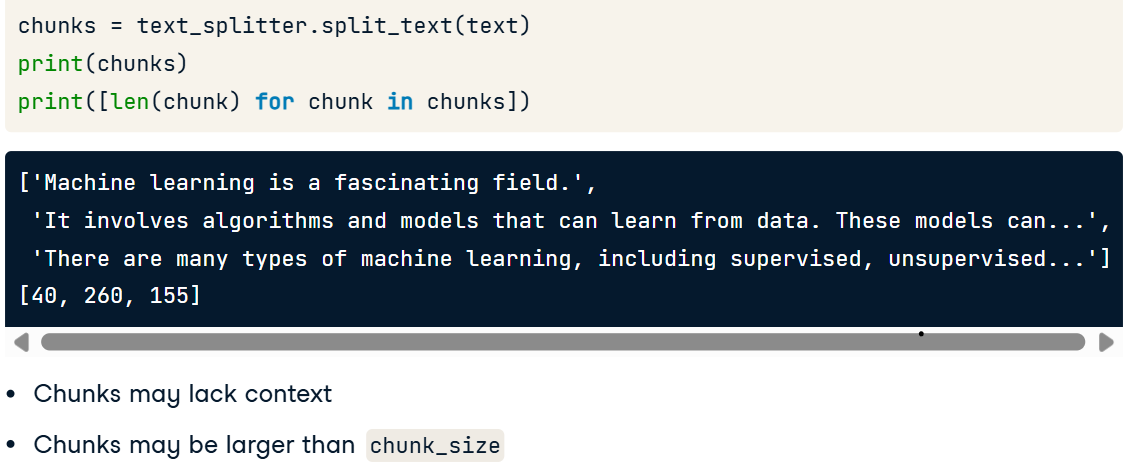

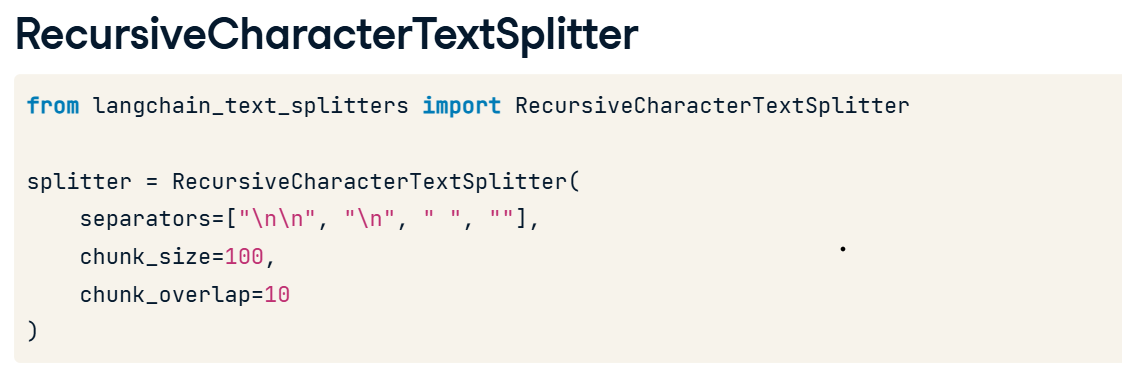
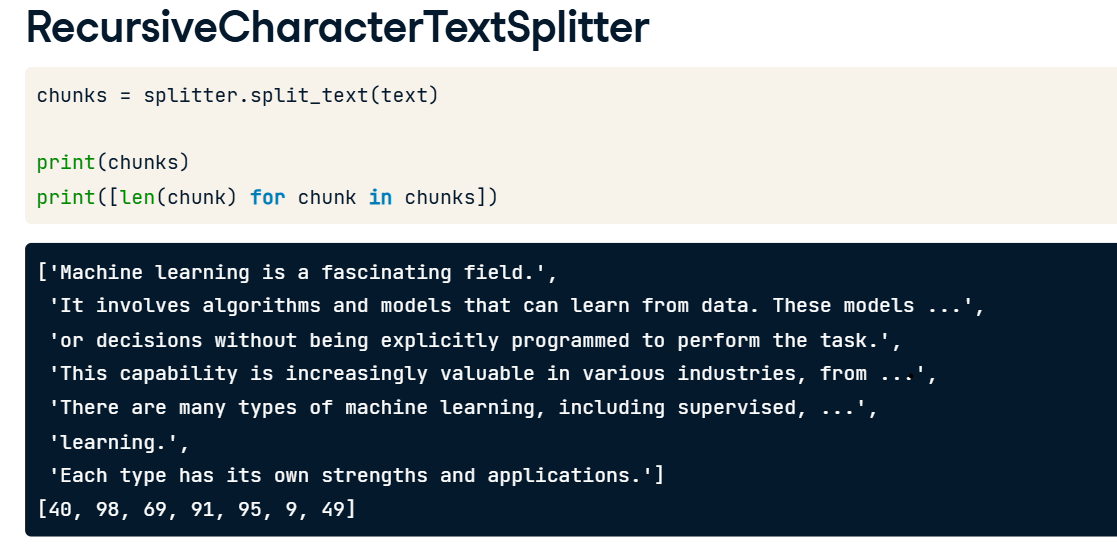

#### Also, to split the documents, we can load the documents and use split_documents() instead of split_text()

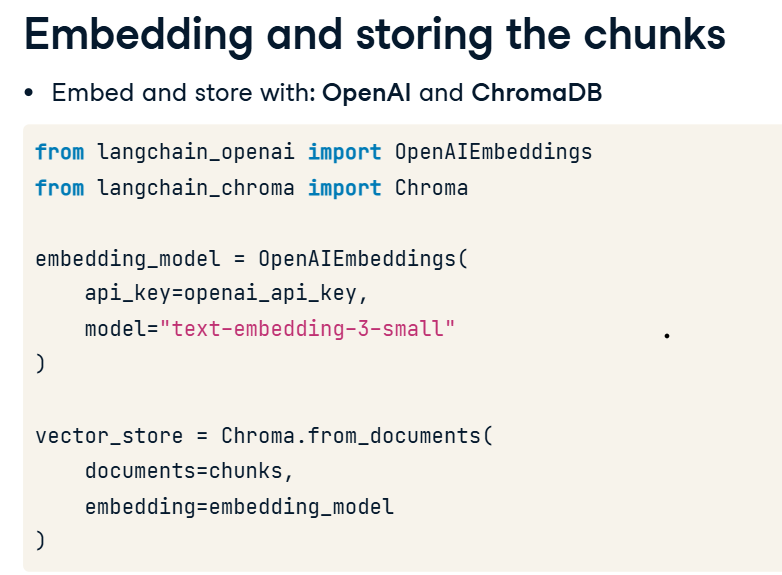


### Building an LCEL retrieval chain
LangChain Expression Language, or LCEL, is a declarative syntax for defining chains suited from prototypes to production. It is particularly relevant to RAG systems because it creates modular, reusable pipelines that can combine retrieval and generation components together. The retrieval chain will take a question input, insert it into the chain using RunnablePassthrough and assign it to "question". RunnablePassthrough allows inputs to be inserted into chains unchanged.

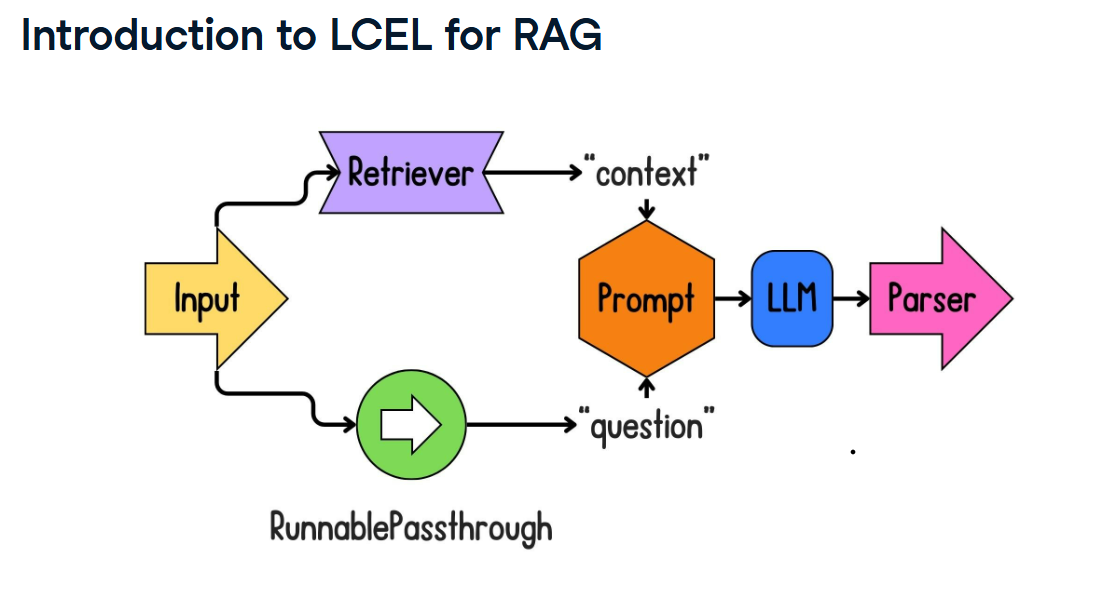
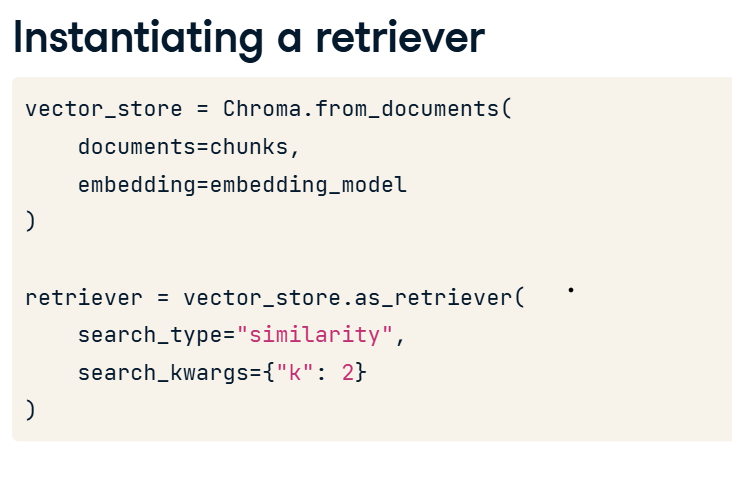
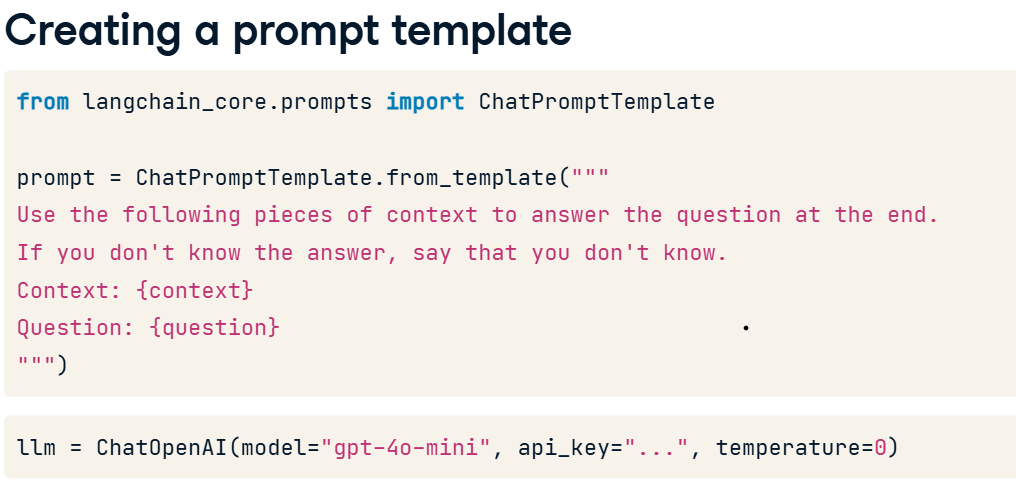
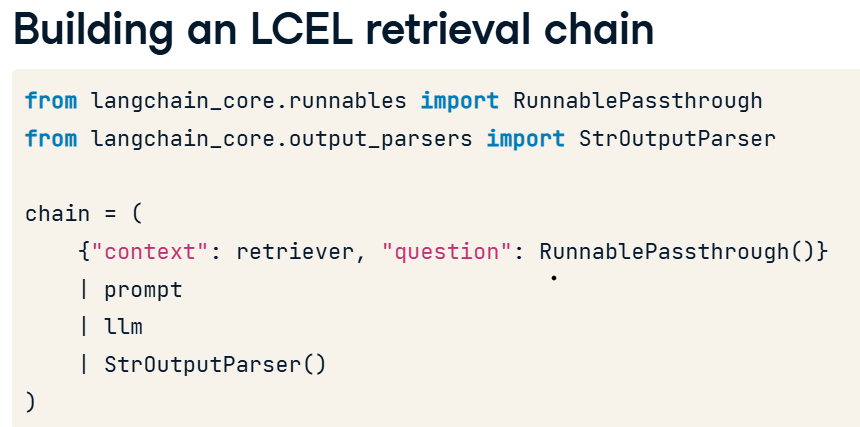
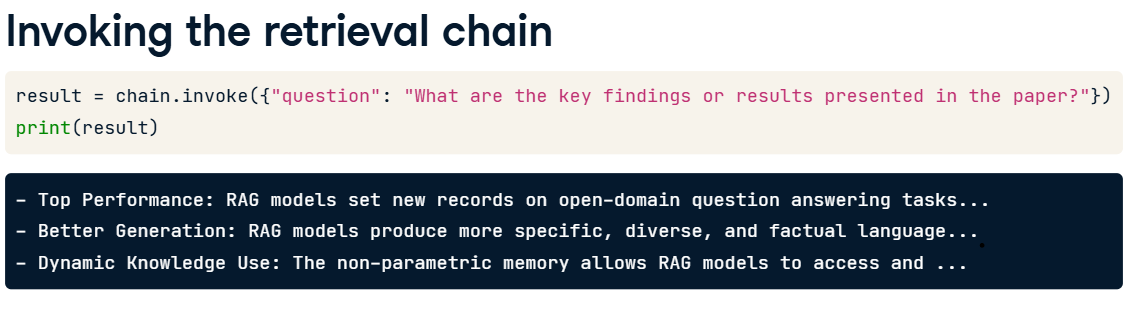

# Part 2: Improving the RAG architecture

## Loading and splitting the code files
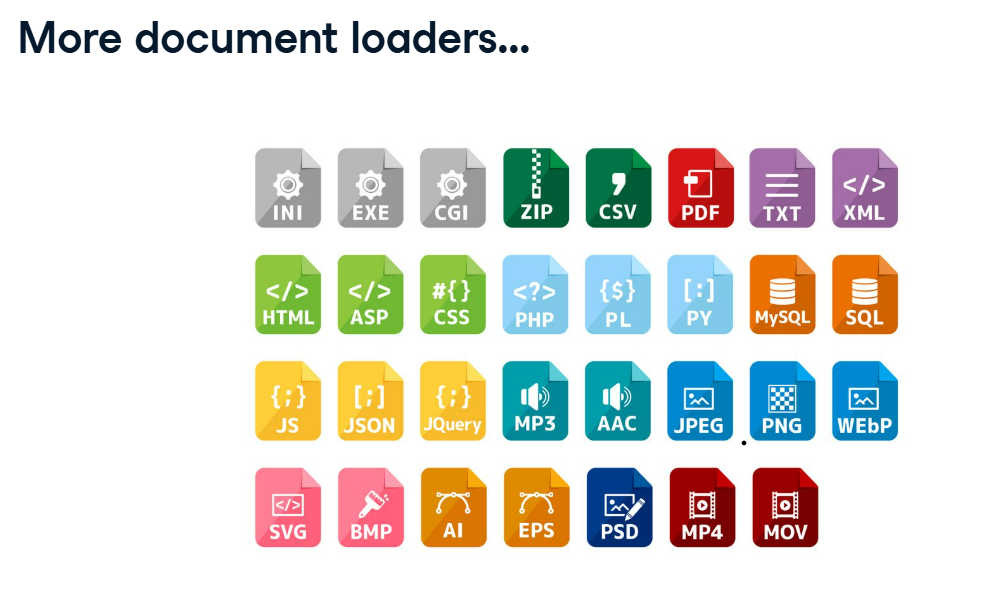

### Markdown file
Markdown is a lightweight markup language for creating formatted documents, and it's often the tool of choice for writing code documentation.
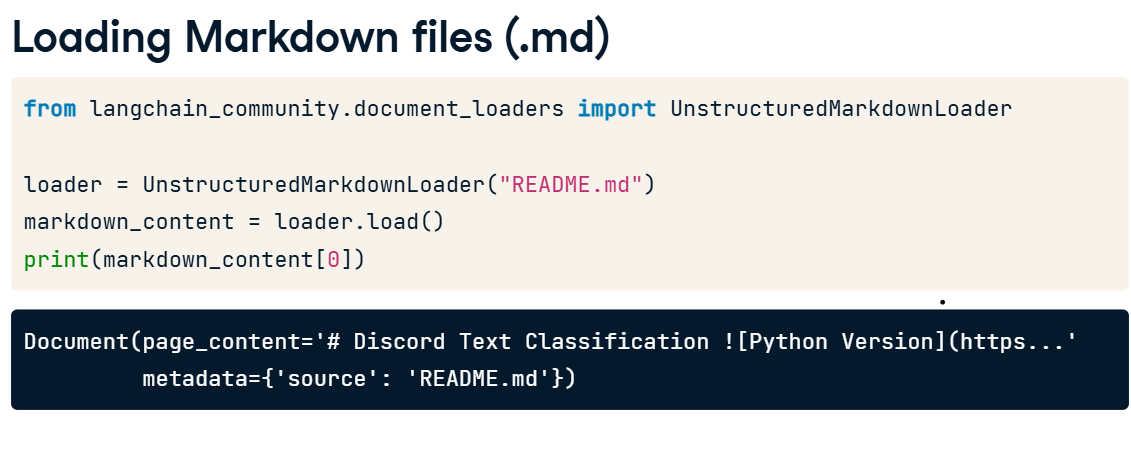

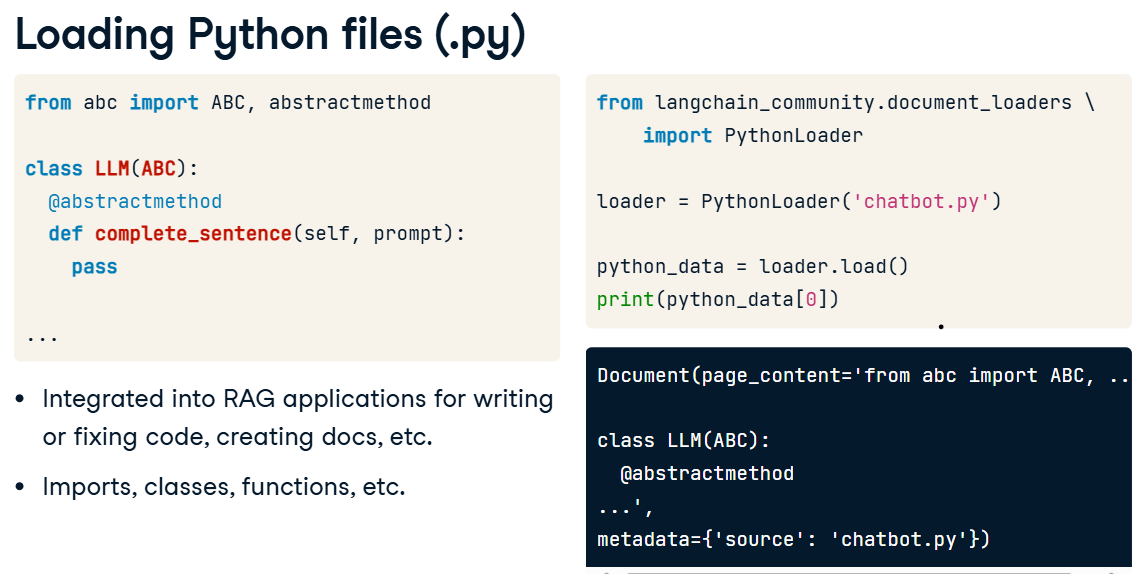

### splitting code files
When we are splitting the code files like python file, if we use the usual RecursiveCharacterTextSplitter only, it may fail to maintain the context because chunks are processed separately, key context has been lost. Our current strategy is naive because it doesn't consider structures like classes and functions.

So to avoid this problem, we use RecursiveCharacterTextSplitter but with .from_language() method.

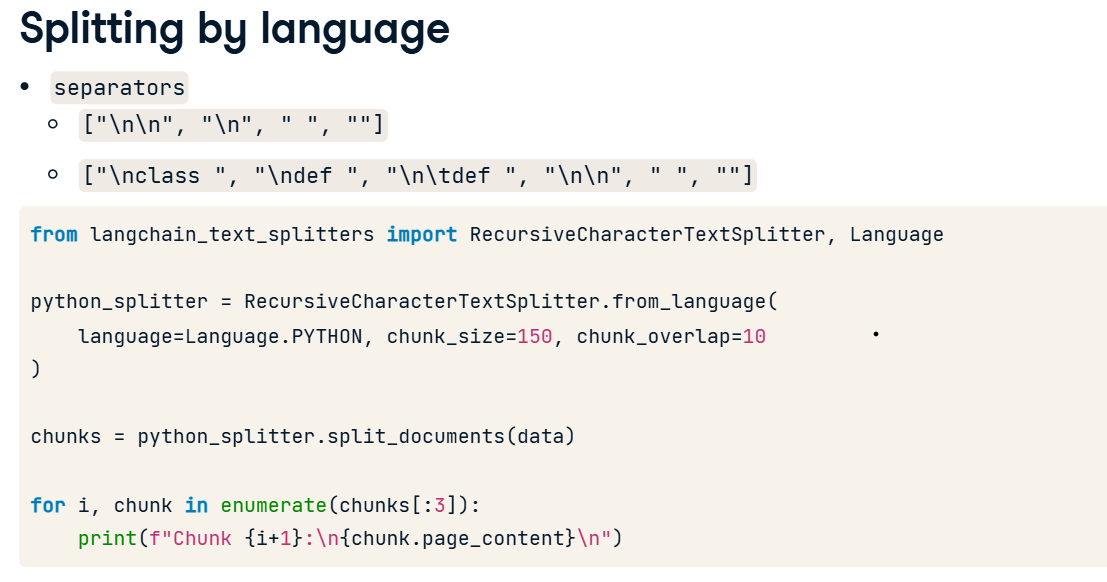

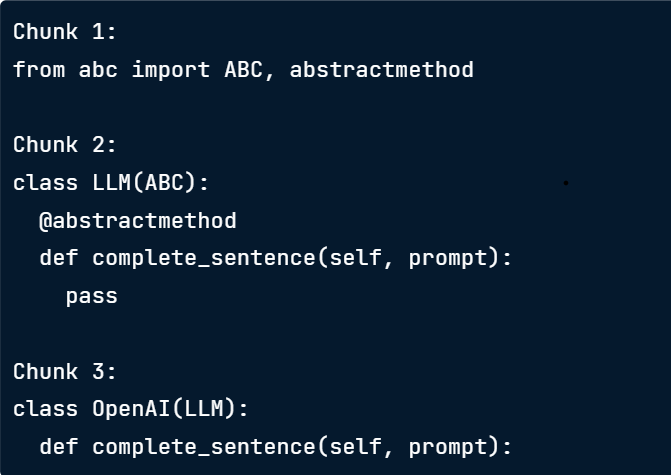

## Advanced Splitting methods
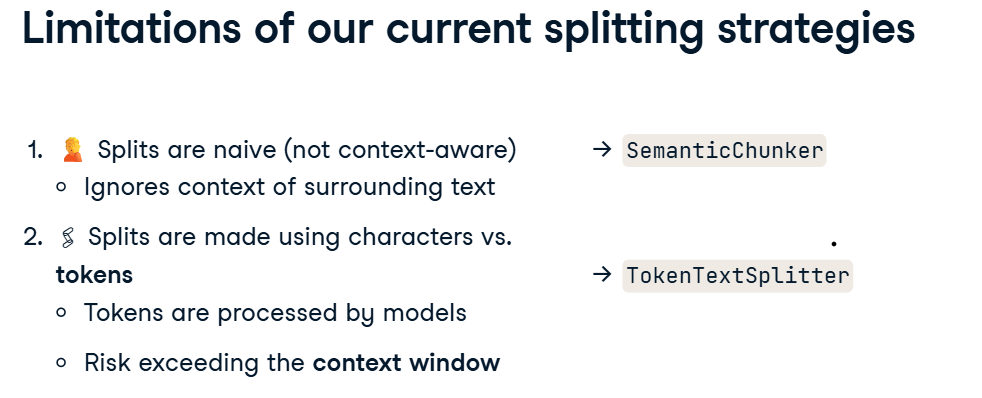

When we use a character text splitter with a chunk_size and chunk_overlap, we get chunks containing groups of characters that satisfy the chunking parameters.

When we split on tokens, the chunk_size and chunk_overlap refer to the number of tokens in the chunk, rather than characters, so a chunk_size of five means we can have a maximum of five tokens in the chunk.

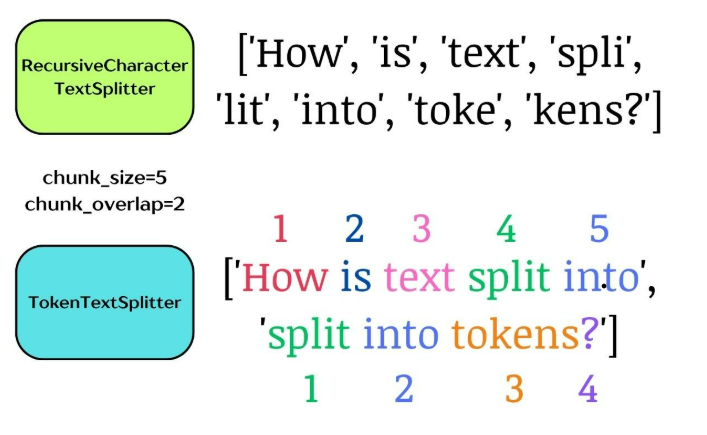

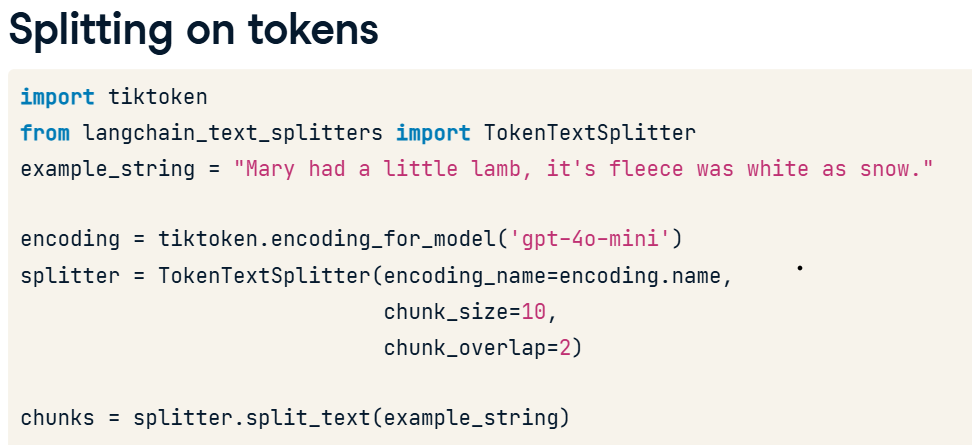

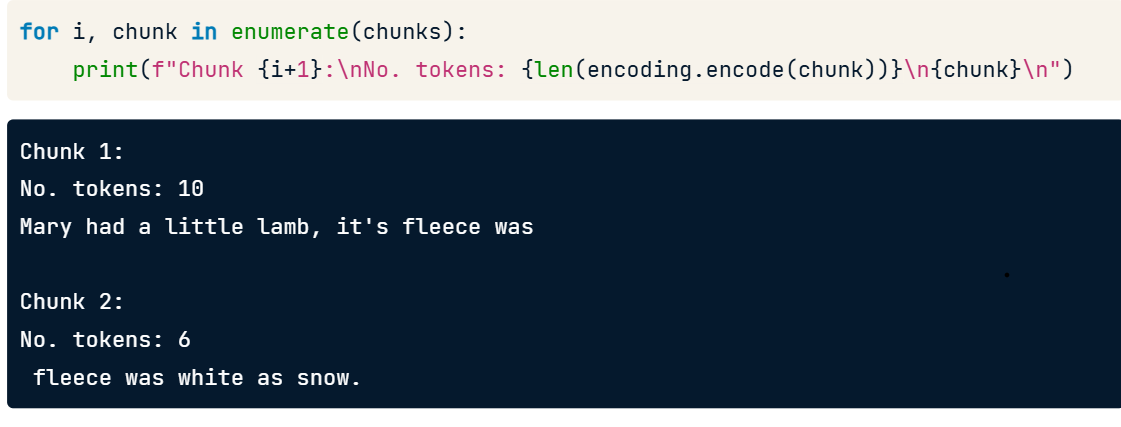

#### A character or token text splitter will split naively, which results in lost context. so we use semantic splitting
A semantic splitter will detect shifts in semantic meaning and perform the splits in those locations; in this example, when the discussion shifts from RAG to dogs.

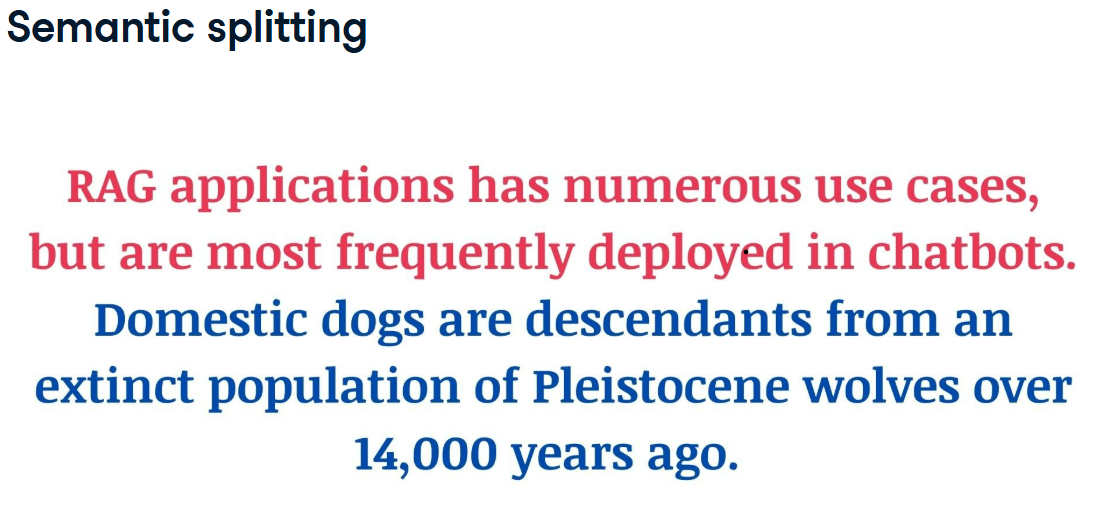

We pass two additional parameters: breakpoint_threshold_type, which sets the metric at which embeddings are compared, and breakpoint_threshold_amount, which sets the metric's threshold at which to perform the split.

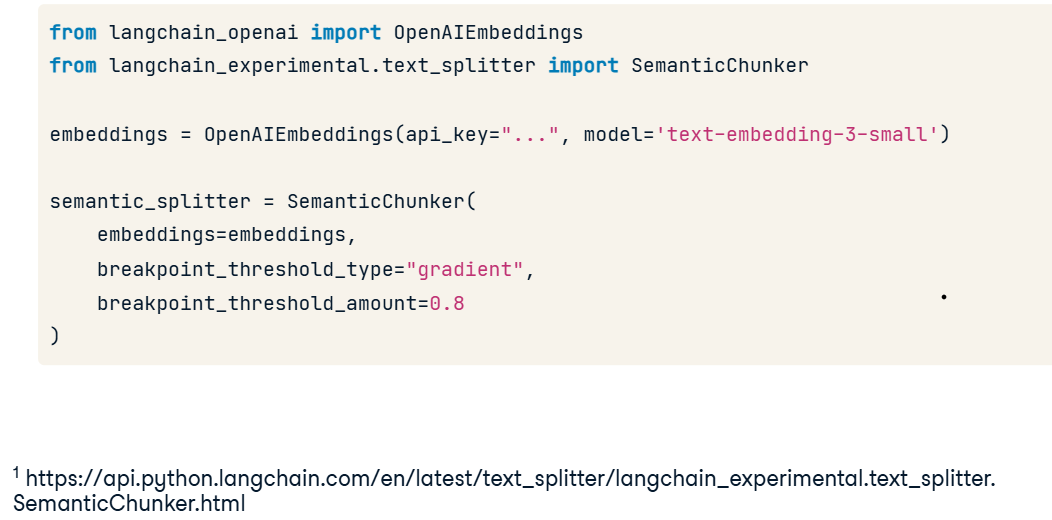

## Optimizing document retrieval
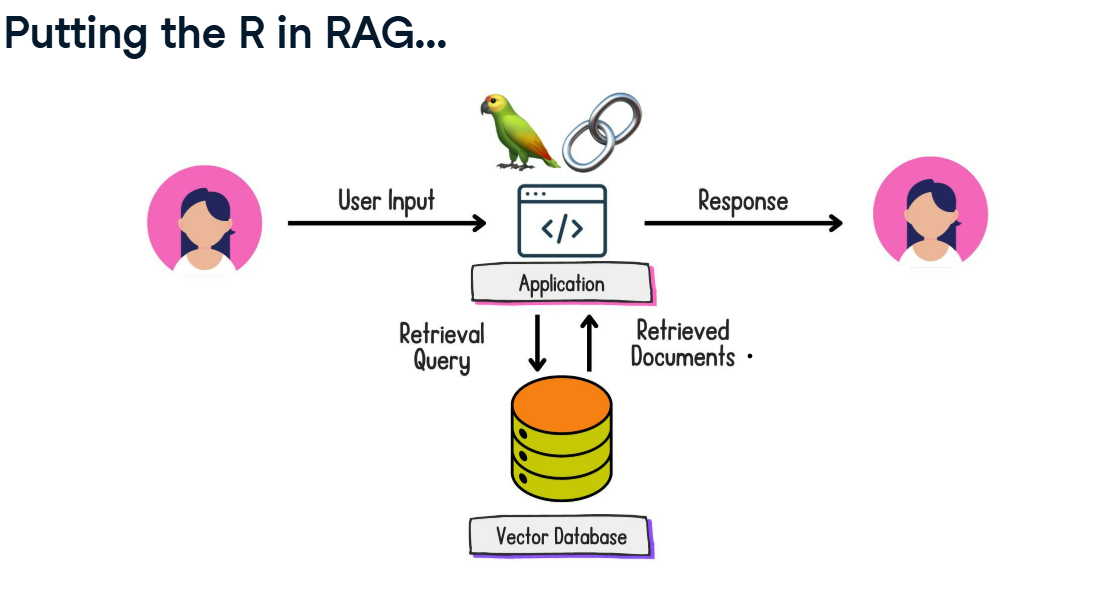

So far, our document retrieval has consisted of a vector database containing embedded documents. The input to the RAG application is then used to query the vectors, using a distance metric to determine which vectors are closest and therefore most similar and relevant. This type of retrieval is known as dense retrieval.

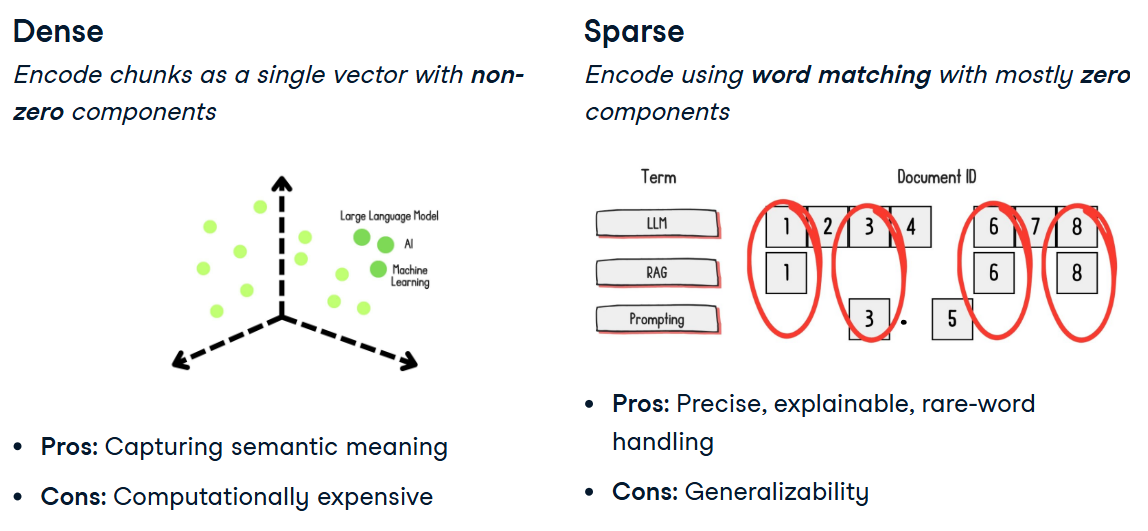

TF-IDF and BM25 are the two popular methods for encoding text as spare vectors. TF-IDF, or Term Frequency-Inverse Document Frequency, creates a sparse vector that measures a term's frequency in a document and rarity in other documents. This helps in identifying words that best represent the document's unique content. BM25, or best matching 25, is an improvement on TF-IDF that prevents high-frequency words from being over-emphasized in the encoding.

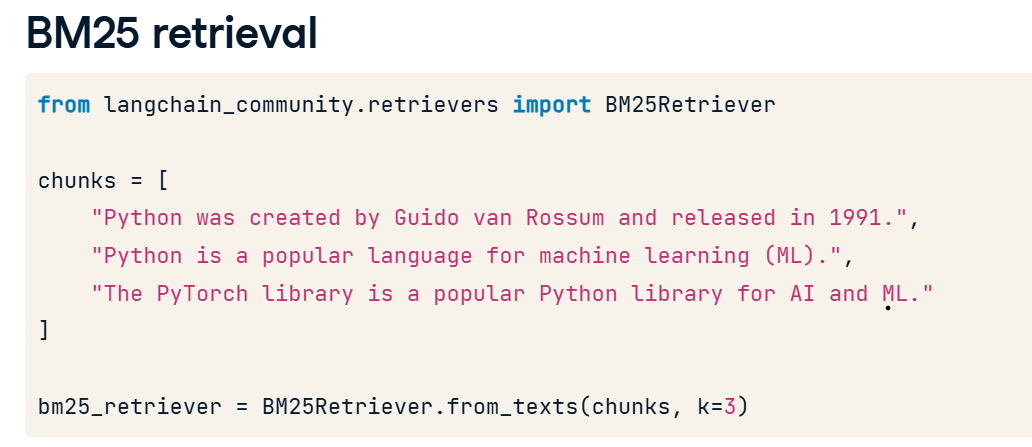

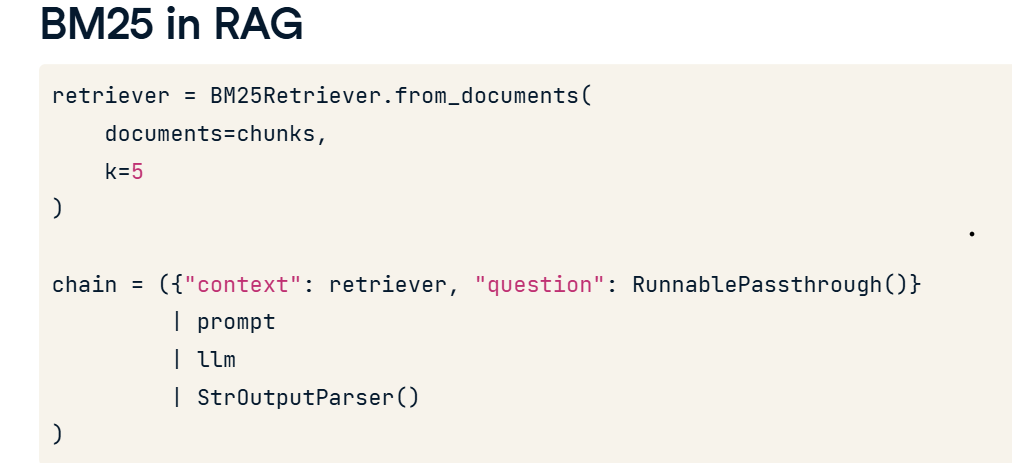

## RAG evaluation
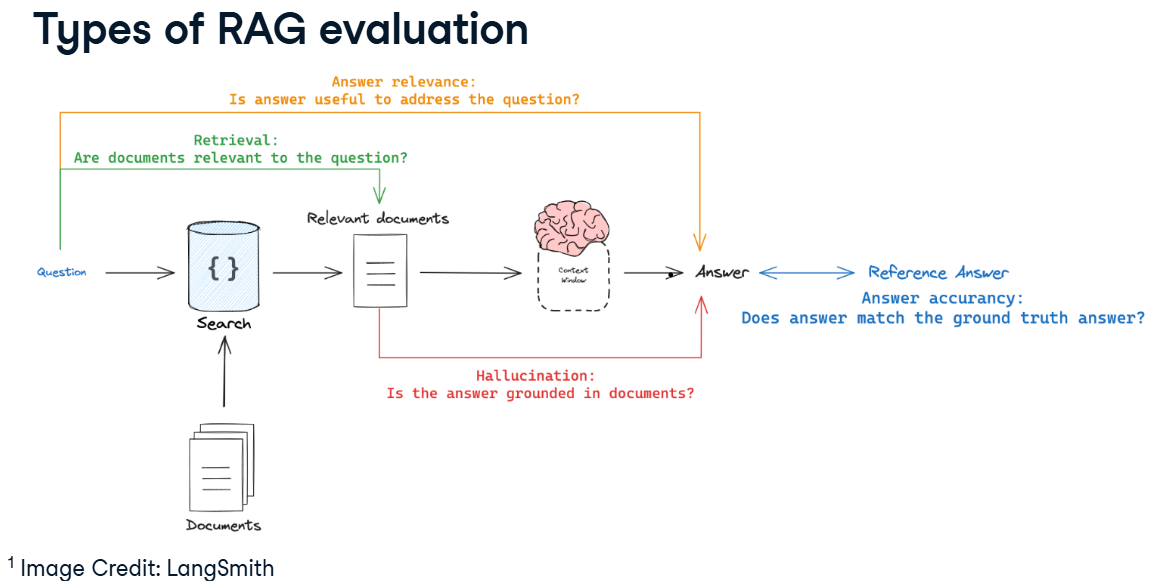

We can use LLMs to measure the correctness of the final output by comparing it to a reference answer. We'll assign the query, model's answer, and reference answer to compare with the following variables.
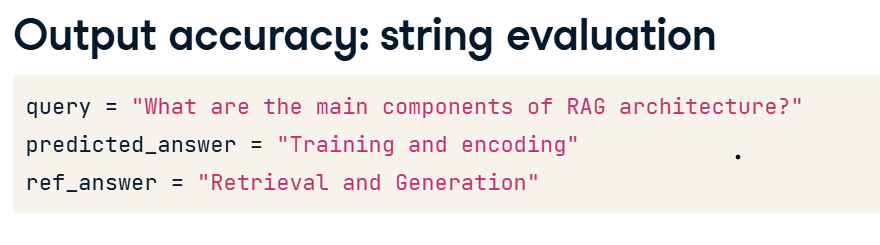

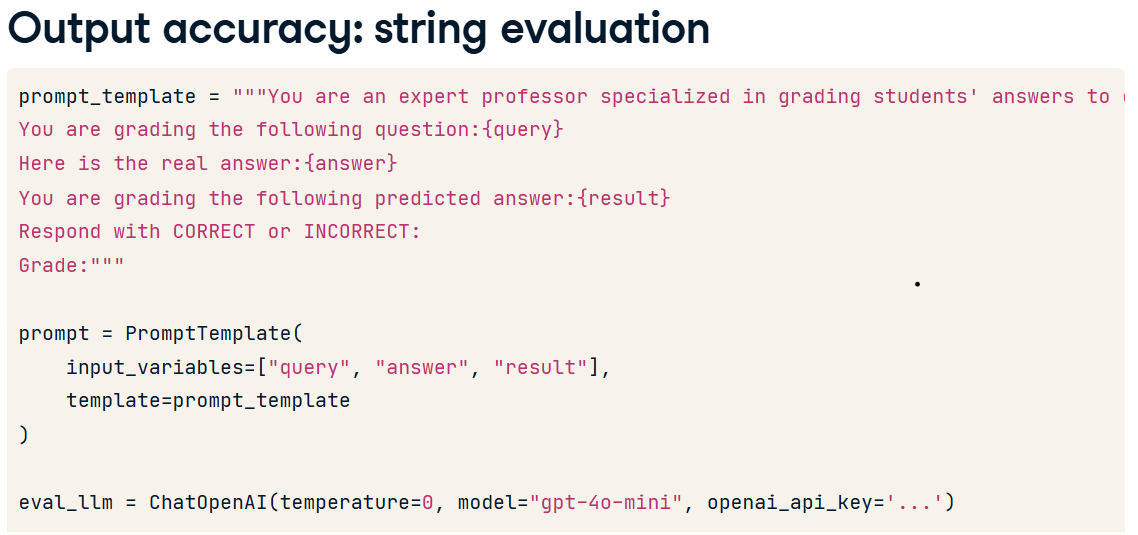

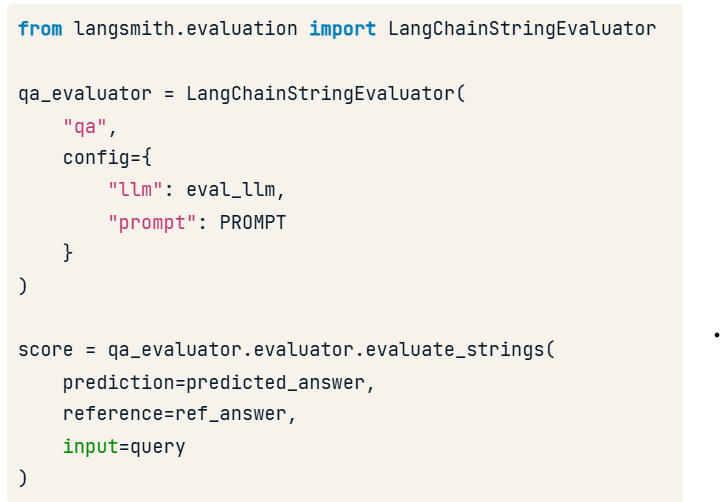

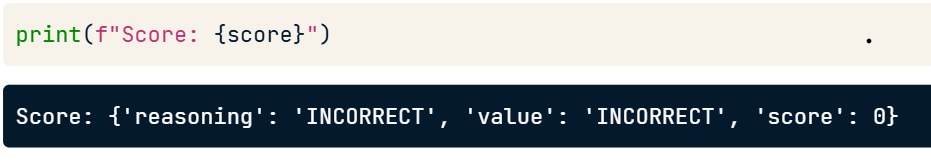

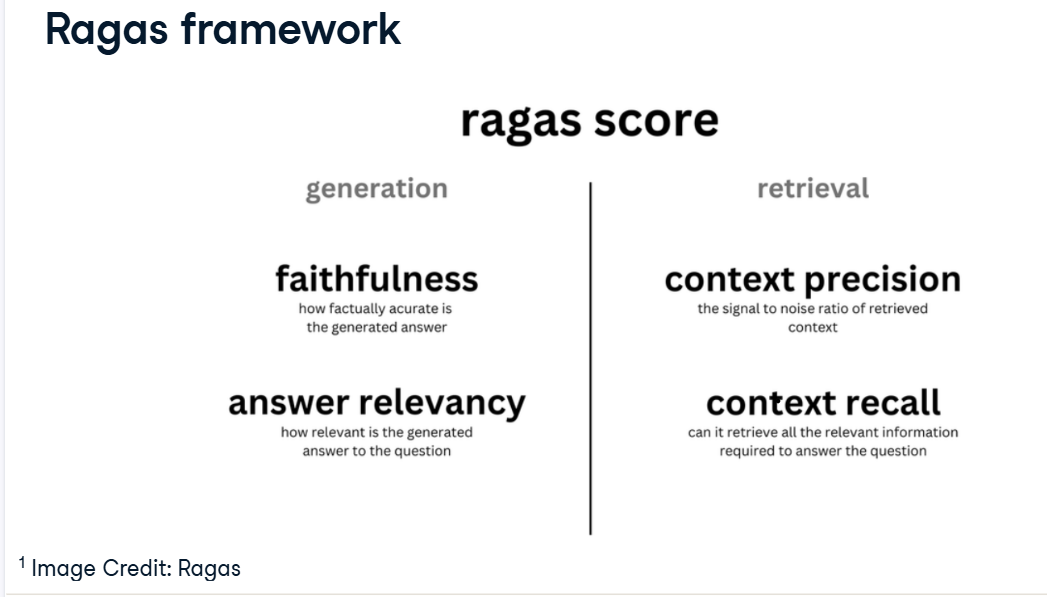

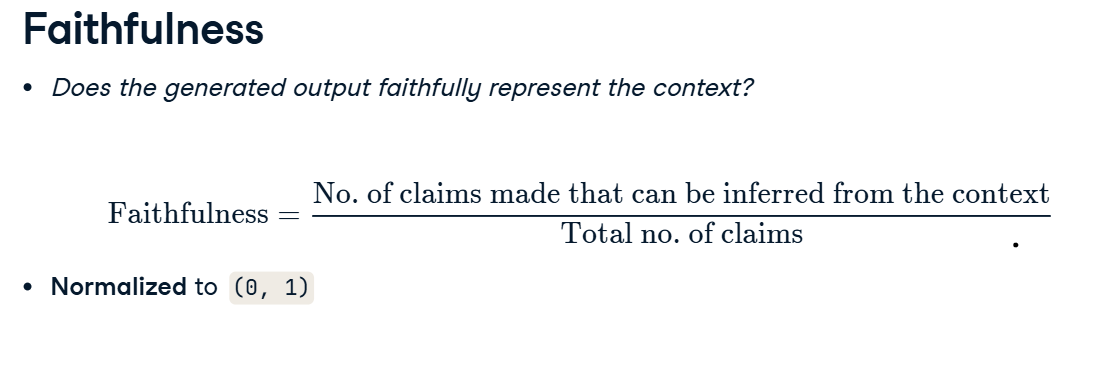

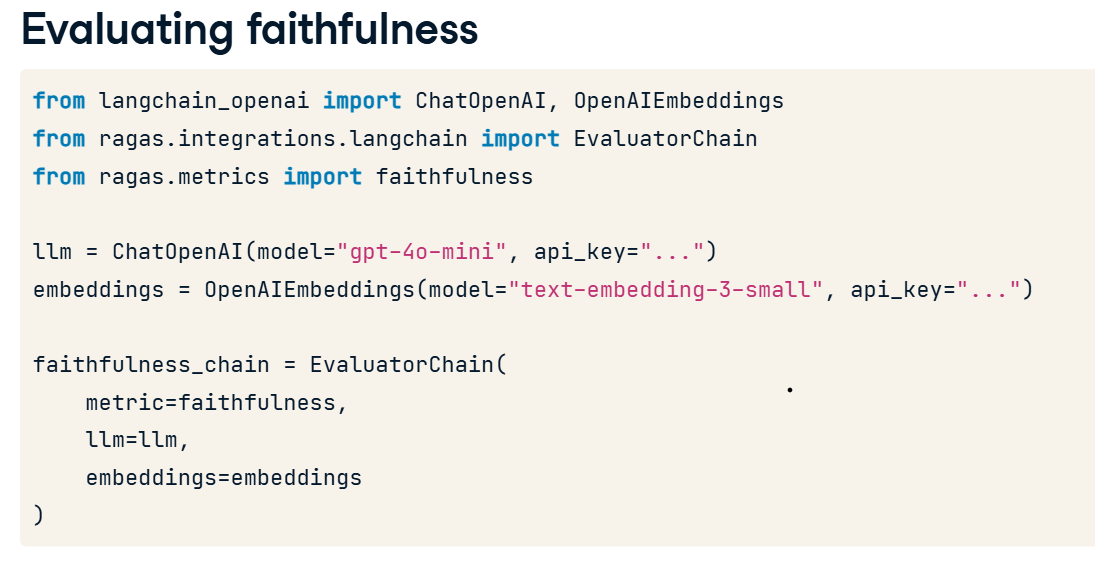

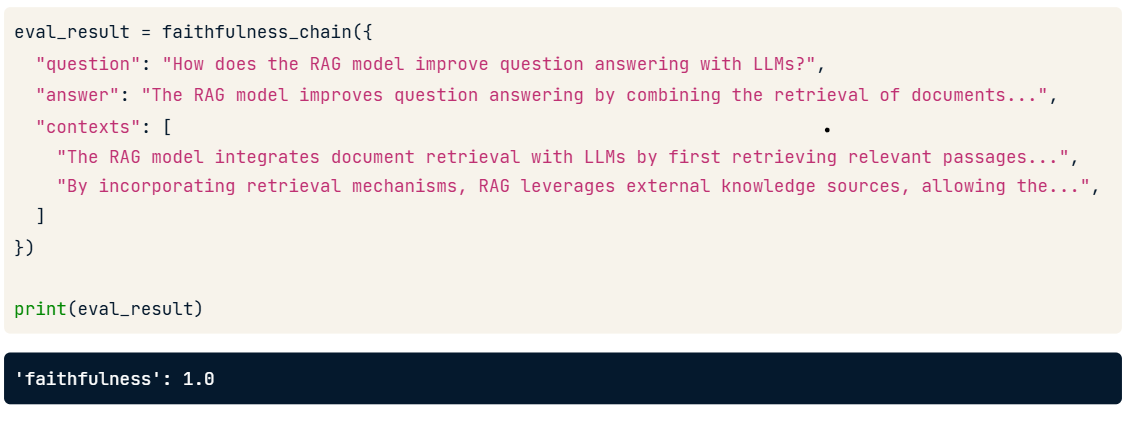

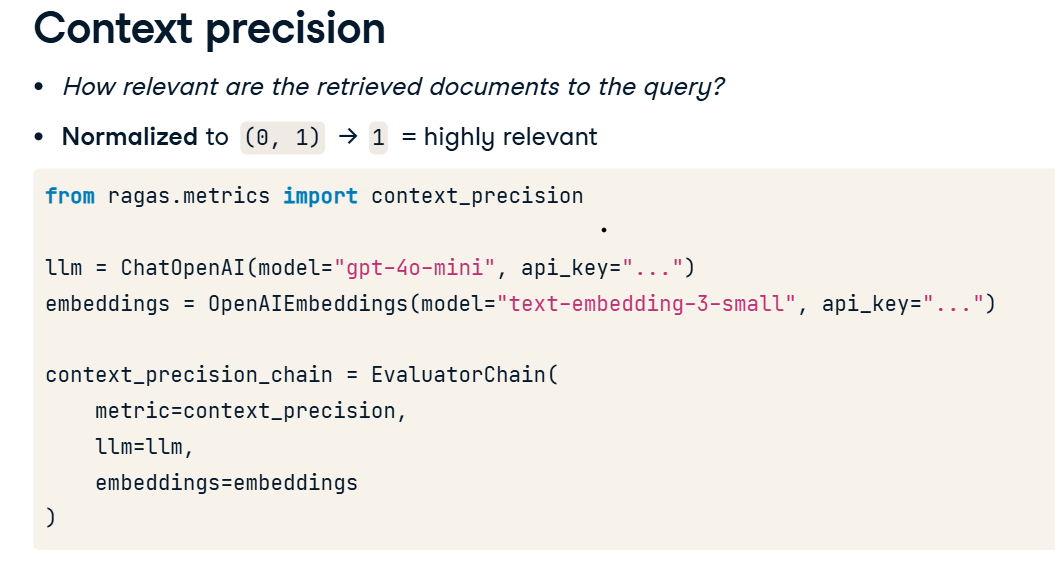

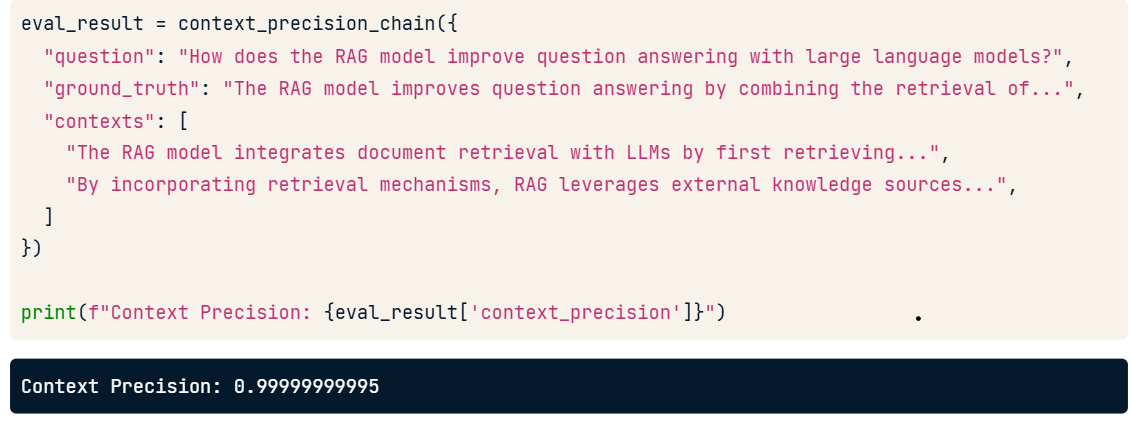

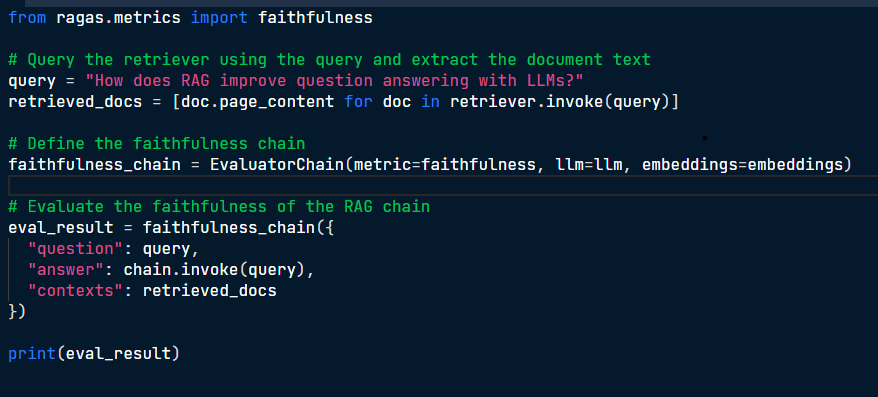

# Part 3: Introduction to graph RAG


## From vectors to graph
The RAG architectures we've explored involve embedding a user input and querying a vector store to return relevant documents based on their semantic similarity. Although powerful, this approach does have some limitations. Firstly, document embedding captures semantic meaning but struggles to capture themes and relationships between entities in the document corpus.

Moreover, as the volume of the database grows, the retrieval process can become less efficient, as the computational load increases with the search space.

Lastly, vector RAG systems don't easily accommodate structured or diverse data, which are harder to embed.

We can address all of those challenges with graphs. Graphs are great at representing and storing diverse and interconnected information in a structured manner.

#### Neo4j graph databases
Neo4j is a powerful graph database option designed to store and efficiently query complex relationships.

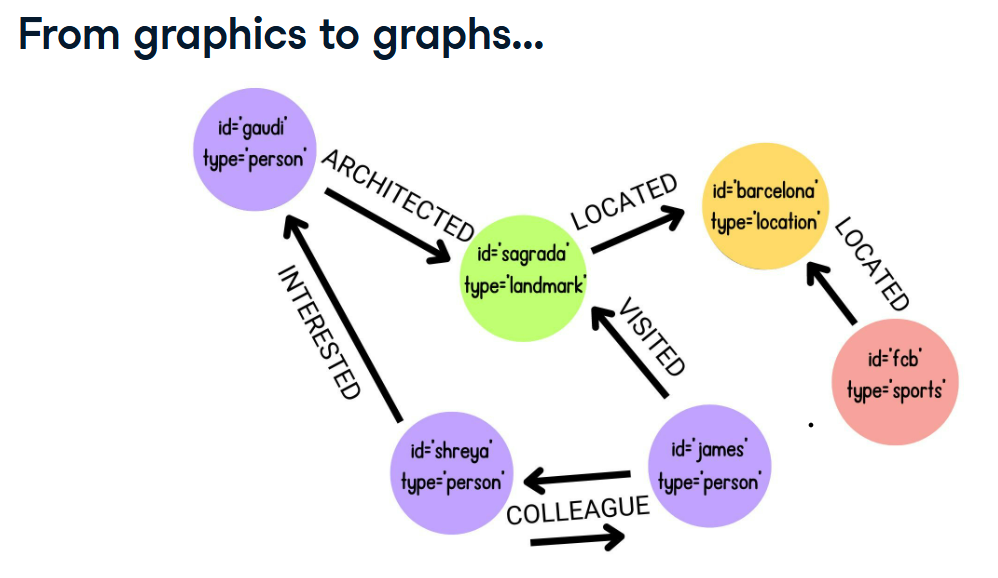

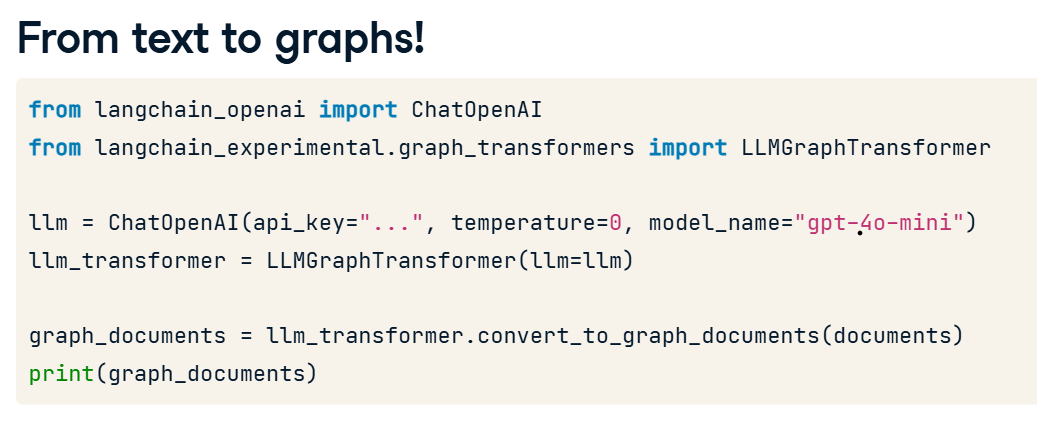

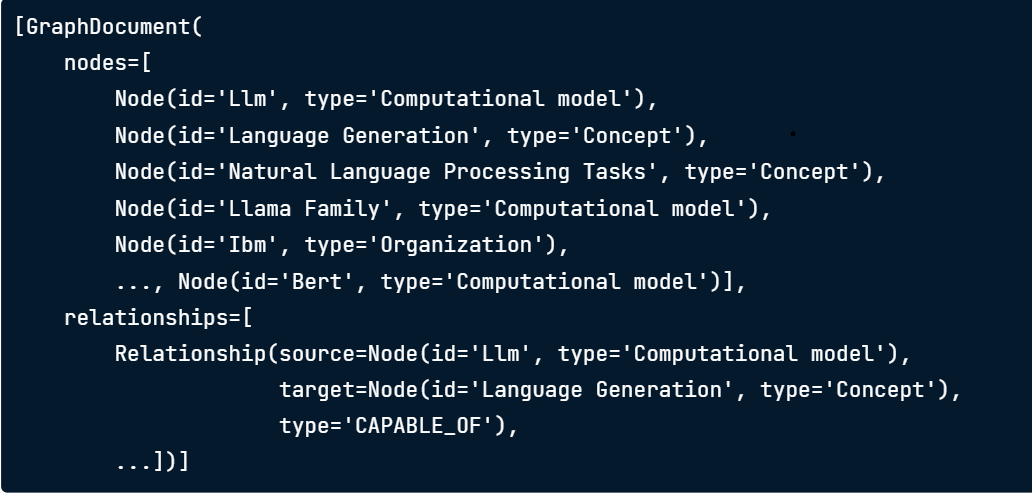

## Storing and Querying documents
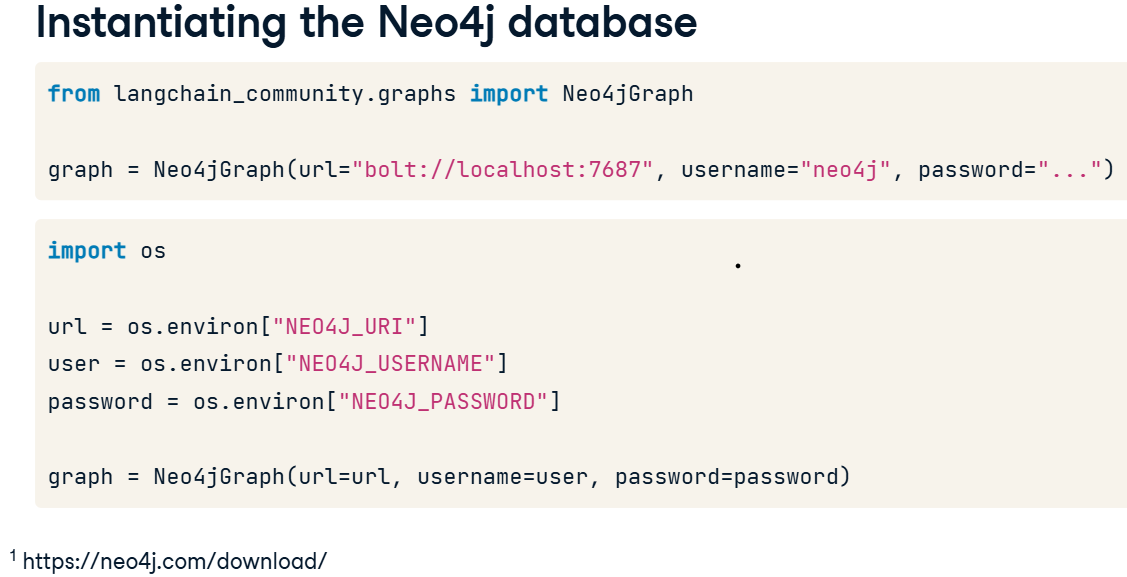

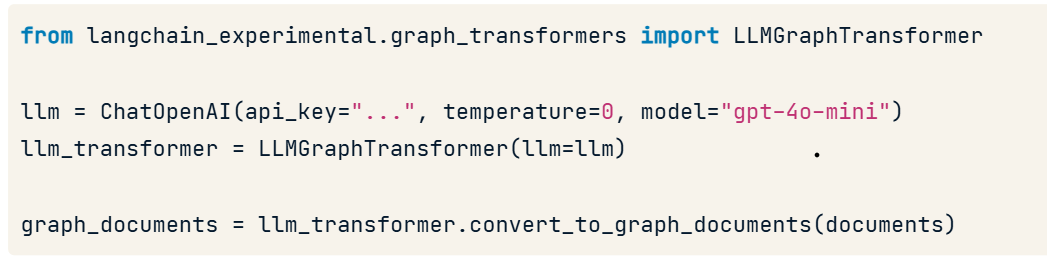

The include_source parameter links nodes to their source documents, which are also represented as nodes, by including a MENTIONS relationship in the graph, enabling better traceability and context preservation. The baseEntityLabel parameter assigns an additional __Entity__ label to each node, improving query performance.

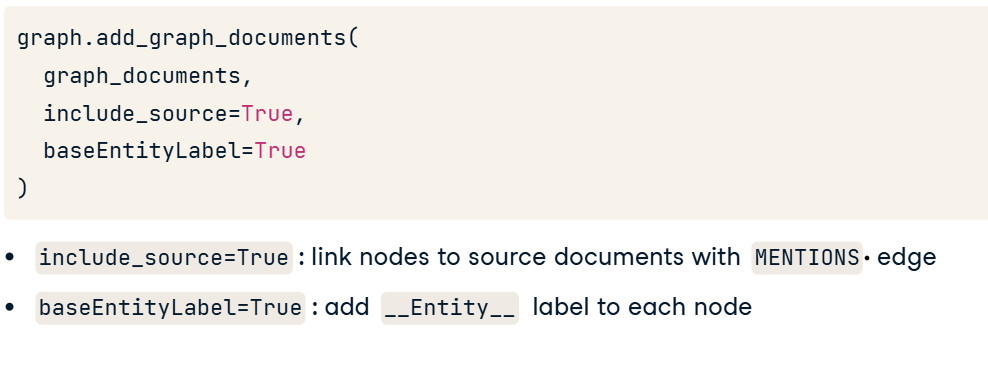

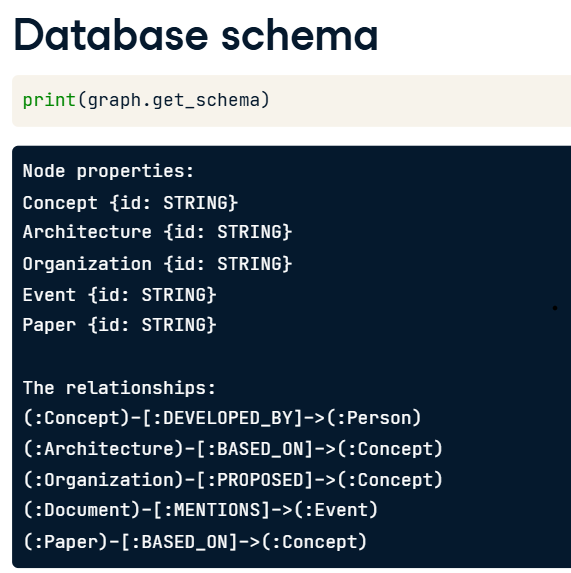

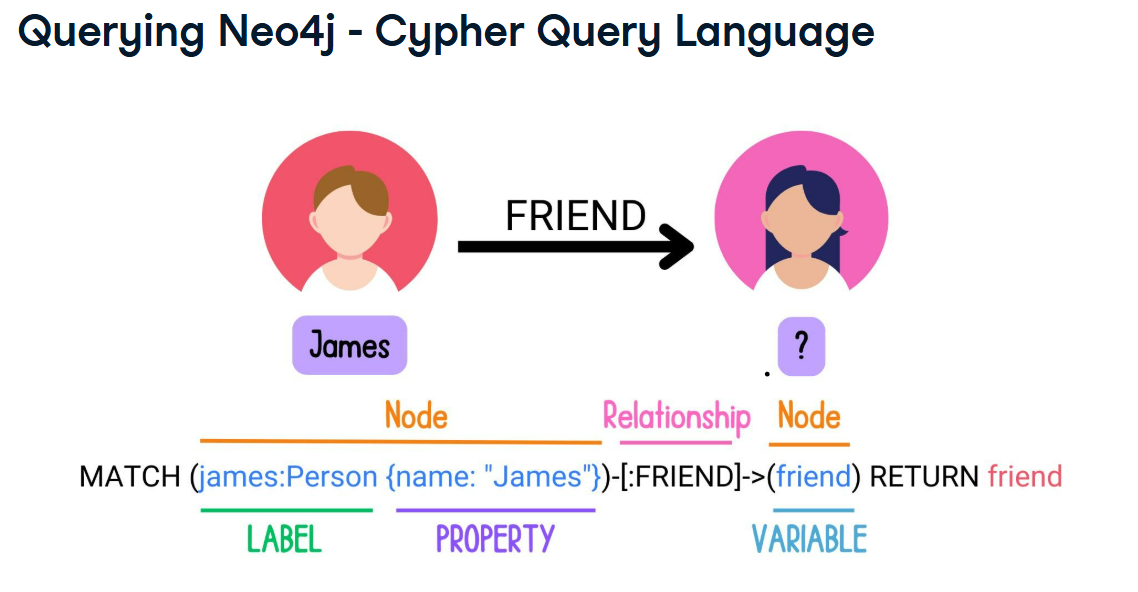

The code looks for a match between a node with name "James" and another node, indicated with the friend variable, joined with a FRIEND relationship. Notice that the relationship sits in the center of an arrow that indicates the direction of the relationship from one node to another.

Person is the node label, we're declaring the source node using the name property, and friend is a variable we'll use to search for the missing name. Notice the code finishes with RETURN friend, so the mystery friend is revealed.

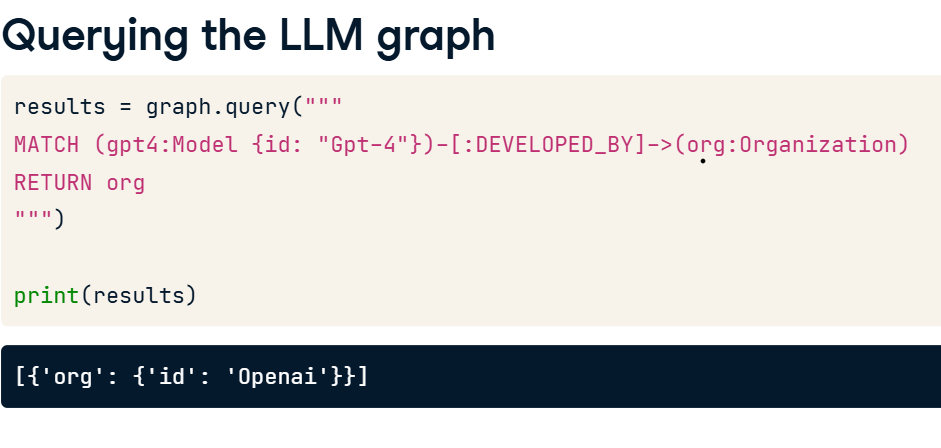

## Graph RAG chain
We need a way to translate our user input into a Cypher query, analogous to how we embed user queries in vector RAG applications, and then return the graph result in natural language.

LangChain provides a GraphCypherQAChain class that performs this translation for us. The user submits a natural language input, it gets translated into a Cypher query, and the generated Cypher is used to query the Neo4j database. Finally, the results obtained from the Neo4j database query are converted back into natural language for the user.

This GraphCypherQAChain is really two sequential chains under the hood: a generate Cypher chain to generate the Cypher query, and a summarize results chain to return the natural language response.

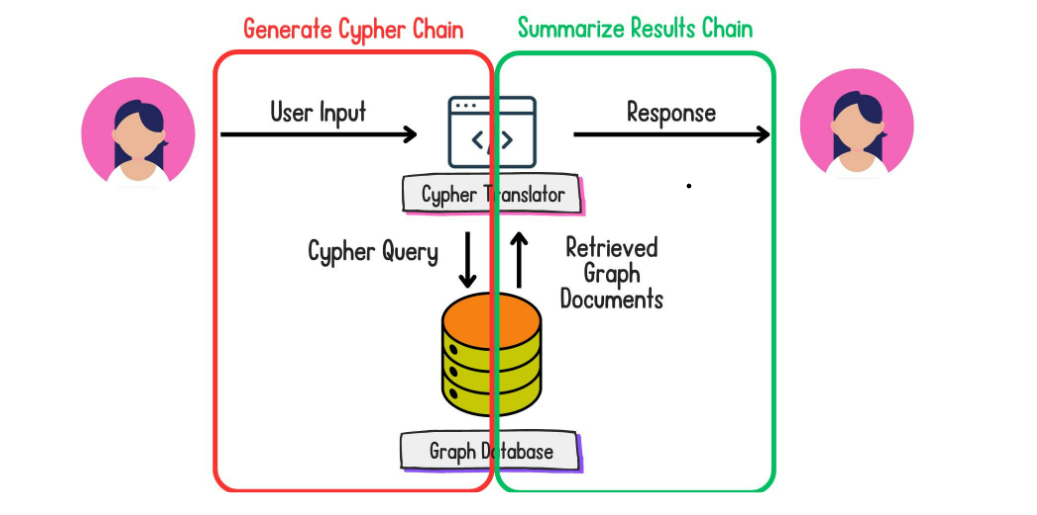

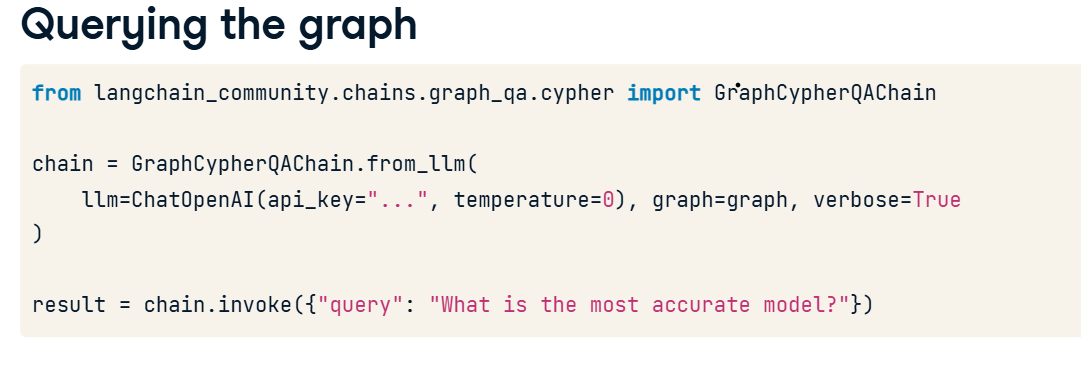

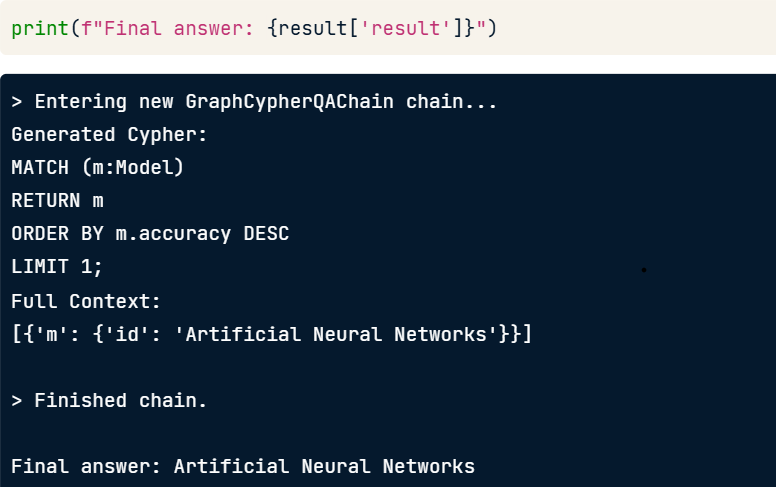

We can see that the chain successfully created a Cypher query that finds all Model nodes in the database, sorts them by their accuracy property in descending order, and returns the node with the highest accuracy. The context shows the query result, which is also reflected in the chain result.

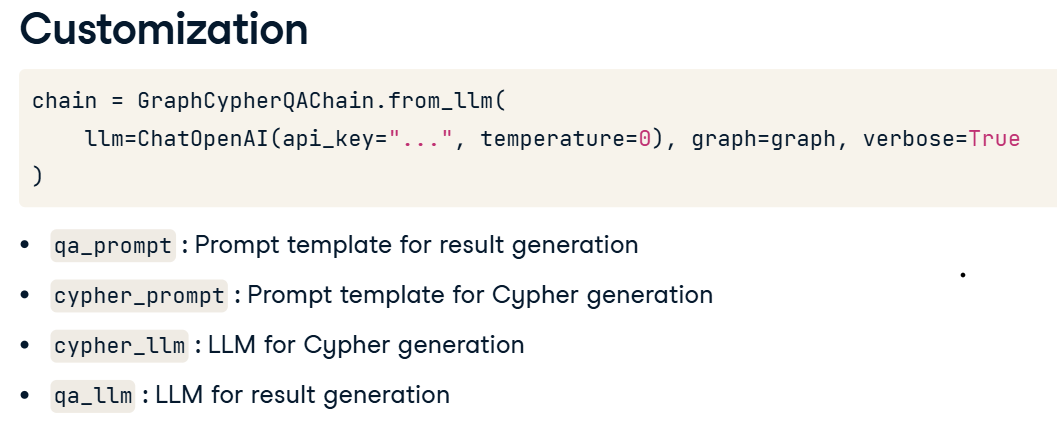
